In [1]:
# ============================================
# PROJECT 1: California Housing Price Prediction
# Author: Diell Fazliu
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 50)
print("CALIFORNIA HOUSING PRICE PREDICTION")
print("=" * 50)

# ============================================
# 1. LOAD AND EXPLORE DATA
# ============================================
print("\n📊 STEP 1: Loading Data...")
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"✅ Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📋 Column names:")
for col in df.columns:
    print(f"   - {col}")

print(f"\n📈 Target variable: {housing.target_names[0]}")

print(f"\n🔍 First 5 rows:")
print(df.head())

print(f"\n🔍 Missing values:")
print(df.isnull().sum())

print(f"\n📊 Statistical Summary:")
print(df.describe().round(2))

CALIFORNIA HOUSING PRICE PREDICTION

📊 STEP 1: Loading Data...
✅ Dataset loaded successfully!
   Shape: 20640 rows, 9 columns

📋 Column names:
   - MedInc
   - HouseAge
   - AveRooms
   - AveBedrms
   - Population
   - AveOccup
   - Latitude
   - Longitude
   - MedHouseVal

📈 Target variable: MedHouseVal

🔍 First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

🔍 Missing values:
MedInc         0
HouseAge       0


STEP 2: Exploratory Data Analysis


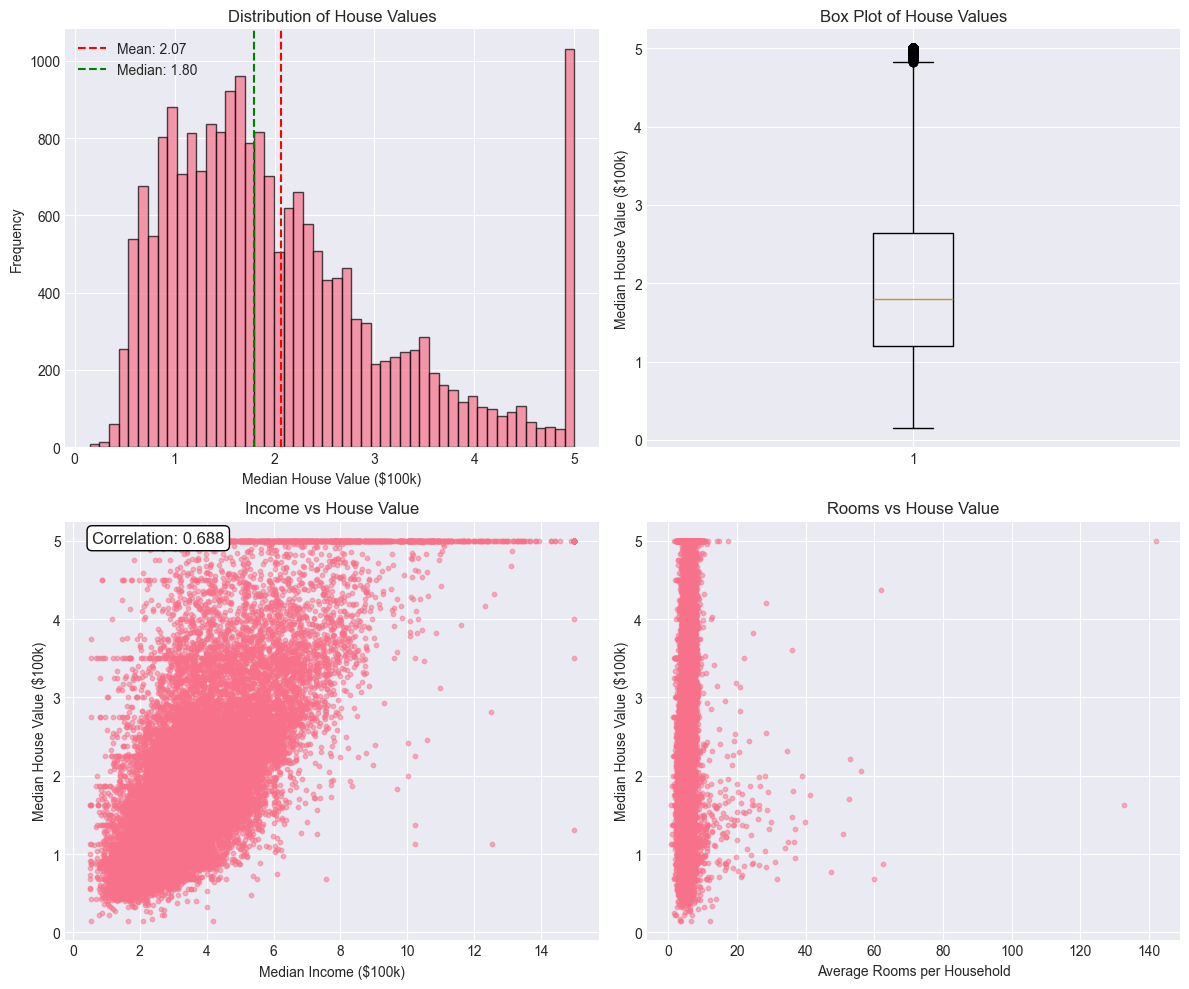

✅ EDA plots saved as 'eda_plots.png'

📈 Feature Correlations with Target:
   MedHouseVal: 1.000
   MedInc: 0.688
   AveRooms: 0.152
   HouseAge: 0.106
   AveOccup: -0.024
   Population: -0.025
   Longitude: -0.046
   AveBedrms: -0.047
   Latitude: -0.144


In [2]:
# ============================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
print("\n" + "=" * 50)
print("STEP 2: Exploratory Data Analysis")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(df['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Median House Value ($100k)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of House Values')
axes[0, 0].axvline(df['MedHouseVal'].mean(), color='red', linestyle='--', label=f'Mean: {df["MedHouseVal"].mean():.2f}')
axes[0, 0].axvline(df['MedHouseVal'].median(), color='green', linestyle='--', label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0, 0].legend()

axes[0, 1].boxplot(df['MedHouseVal'])
axes[0, 1].set_ylabel('Median House Value ($100k)')
axes[0, 1].set_title('Box Plot of House Values')

axes[1, 0].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5, s=10)
axes[1, 0].set_xlabel('Median Income ($100k)')
axes[1, 0].set_ylabel('Median House Value ($100k)')
axes[1, 0].set_title('Income vs House Value')
axes[1, 0].text(0.05, 0.95, f'Correlation: {df["MedInc"].corr(df["MedHouseVal"]):.3f}', 
                 transform=axes[1, 0].transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor='white'))

axes[1, 1].scatter(df['AveRooms'], df['MedHouseVal'], alpha=0.5, s=10)
axes[1, 1].set_xlabel('Average Rooms per Household')
axes[1, 1].set_ylabel('Median House Value ($100k)')
axes[1, 1].set_title('Rooms vs House Value')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ EDA plots saved as 'eda_plots.png'")

print("\n📈 Feature Correlations with Target:")
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
for feature, corr in correlations.items():
    print(f"   {feature}: {corr:.3f}")

In [ ]:
# ============================================
# 3. DATA PREPROCESSING
# ============================================
print("\n" + "=" * 50)
print("STEP 3: Data Preprocessing")
print("=" * 50)

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Train set size: {X_train.shape[0]} samples")
print(f"✅ Test set size: {X_test.shape[0]} samples")


STEP 3: Data Preprocessing
Features shape: (20640, 8)
Target shape: (20640,)

✅ Train set size: 16512 samples
✅ Test set size: 4128 samples


In [ ]:
# ============================================
# 4. TRAIN LINEAR REGRESSION MODEL
# ============================================
print("\n" + "=" * 50)
print("STEP 4: Training Linear Regression Model")
print("=" * 50)

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n📊 Feature Importance (Coefficients):")
for _, row in feature_importance.iterrows():
    print(f"   {row['Feature']}: {row['Coefficient']:.4f}")


STEP 4: Training Linear Regression Model
✅ Model trained successfully!

📊 Feature Importance (Coefficients):
   AveBedrms: 0.7831
   MedInc: 0.4487
   Longitude: -0.4337
   Latitude: -0.4198
   AveRooms: -0.1233
   HouseAge: 0.0097
   AveOccup: -0.0035
   Population: -0.0000


In [ ]:
# ============================================
# 5. EVALUATE MODEL & CHECK OVERFITTING
# ============================================
print("\n" + "=" * 50)
print("STEP 5: Model Evaluation")
print("=" * 50)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n📈 TRAINING SET PERFORMANCE:")
print(f"   RMSE: ${train_rmse * 100000:.2f}")
print(f"   MAE:  ${train_mae * 100000:.2f}")
print(f"   R² Score: {train_r2:.4f}")

print("\n📈 TEST SET PERFORMANCE:")
print(f"   RMSE: ${test_rmse * 100000:.2f}")
print(f"   MAE:  ${test_mae * 100000:.2f}")
print(f"   R² Score: {test_r2:.4f}")

print("\n⚠️ OVERFITTING CHECK:")
r2_diff = train_r2 - test_r2
print(f"   R² difference (train - test): {r2_diff:.4f}")

if r2_diff > 0.05:
    print("   ⚠️ Possible overfitting detected! Consider simplifying the model.")
elif r2_diff > 0.02:
    print("   📊 Mild overfitting detected, but acceptable.")
else:
    print("   ✅ Model generalizes well! No significant overfitting.")


STEP 5: Model Evaluation

📈 TRAINING SET PERFORMANCE:
   RMSE: $71967.57
   MAE:  $52862.84
   R² Score: 0.6126

📈 TEST SET PERFORMANCE:
   RMSE: $74558.14
   MAE:  $53320.01
   R² Score: 0.5758

⚠️ OVERFITTING CHECK:
   R² difference (train - test): 0.0368
   📊 Mild overfitting detected, but acceptable.



STEP 6: Visualizing Results


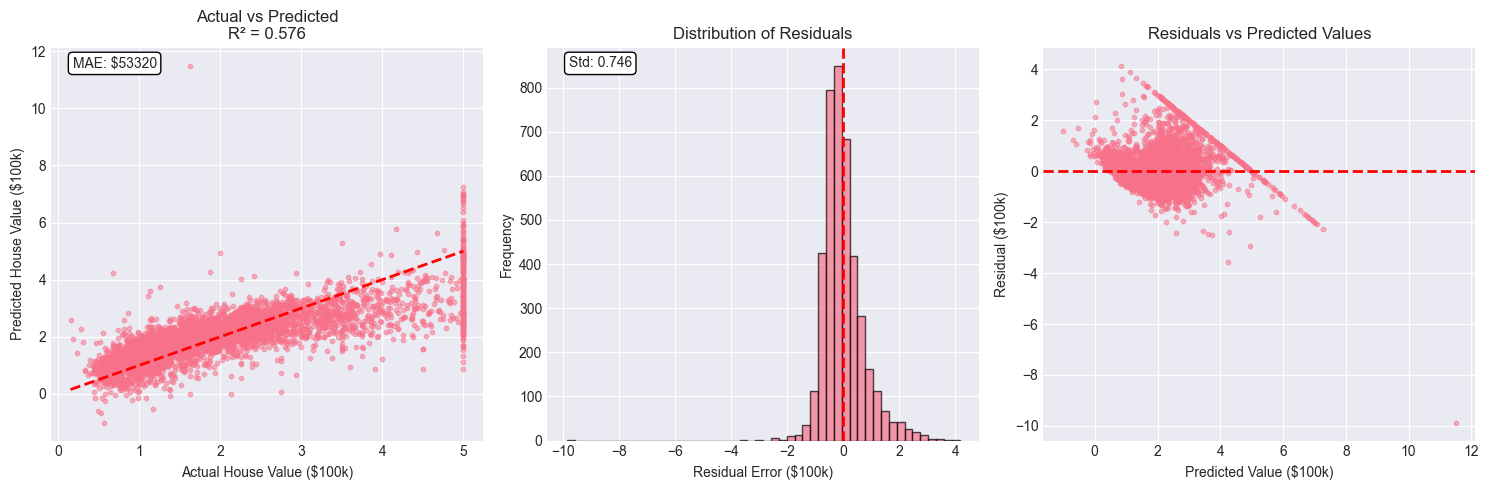

✅ Results plot saved as 'model_results.png'


In [ ]:
# ============================================
# 6. VISUALIZE RESULTS
# ============================================
print("\n" + "=" * 50)
print("STEP 6: Visualizing Results")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title(f'Actual vs Predicted\nR² = {test_r2:.3f}')
axes[0].text(0.05, 0.95, f'MAE: ${test_mae * 100000:.0f}', 
             transform=axes[0].transAxes, fontsize=10, bbox=dict(boxstyle="round", facecolor='white'))

residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual Error ($100k)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].text(0.05, 0.95, f'Std: {residuals.std():.3f}', 
             transform=axes[1].transAxes, fontsize=10, bbox=dict(boxstyle="round", facecolor='white'))

axes[2].scatter(y_test_pred, residuals, alpha=0.5, s=10)
axes[2].axhline(0, color='red', linestyle='--', lw=2)
axes[2].set_xlabel('Predicted Value ($100k)')
axes[2].set_ylabel('Residual ($100k)')
axes[2].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Results plot saved as 'model_results.png'")

# California Housing Price Prediction

**Author:** Diell Fazliu  
**Goal:** Predict median house values using Linear Regression

## Project Overview
This project demonstrates:
- Data cleaning and preprocessing
- Handling categorical variables
- Linear regression modeling
- Overfitting detection

# California Housing Price Prediction

**Author:** Diell Fazliu  
**Goal:** Predict median house values using Linear Regression

## Project Overview
This project demonstrates:
- Data cleaning and preprocessing
- Handling categorical variables
- Linear regression modeling
- Overfitting detection

# California Housing Price Prediction

**Author:** Diell Fazliu  
**Goal:** Predict median house values using Linear Regression

## Project Overview
This project demonstrates:
- Data cleaning and preprocessing
- Handling categorical variables
- Linear regression modeling
- Overfitting detection